# Customer Segmentation Analysis

**Goal:** group customers into statistically distinct, business-actionable
segments based on demographics and purchasing behavior (RFM: recency,
frequency, monetary value), then turn each segment into a targeted
marketing recommendation.

**Contents**
1. Load Data
2. Data Cleaning
3. Statistical Analysis & EDA
4. Feature Engineering & Scaling
5. Choosing K and Fitting K-Means
6. Cluster Visualization (PCA)
7. Segment Profiling
8. Business Recommendations

> **About the data:** `data/customer_data_raw.csv` is a synthetic dataset
> generated by `scripts/generate_data.py`, built from 5 underlying customer
> archetypes (so the clustering below has real, recoverable structure) with
> realistic messiness layered on top (duplicates, missing values,
> implausible ages, sign errors) for the cleaning section to address. Swap
> in your own customer export with the same columns to segment real data.


## 1. Load Data

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titleweight"] = "bold"

ACCENT = "#2563EB"
PALETTE = ["#2563EB", "#F59E0B", "#10B981", "#EF4444", "#8B5CF6", "#06B6D4"]

df = pd.read_csv("../data/customer_data_raw.csv")
print(f"Raw dataset shape: {df.shape}")
df.head()


Raw dataset shape: (1218, 12)


,CustomerID,Age,Gender,City,AnnualIncome,MembershipTier,PreferredChannel,TenureMonths,RecencyDays,Frequency,MonetaryTotal,AvgBasketValue
0,CUST-10284,35,Female,Portland,36611.45,Basic,In-Store,39,0,19,490.86,17.72
1,CUST-10804,43,Female,Seattle,32160.30,Gold,Online,9,71,2,9.48,65.27
2,CUST-10381,60,Female,Denver,109609.53,Gold,Online,61,19,25,6951.76,166.62
3,CUST-10617,80,Female,Houston,114809.43,Basic,In-Store,19,59,3,1784.26,482.15
4,CUST-10805,18,Male,Austin,41538.42,Basic,Online,6,72,2,40.03,66.76


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1218 entries, 0 to 1217
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        1218 non-null   str    
 1   Age               1218 non-null   int64  
 2   Gender            1206 non-null   str    
 3   City              1200 non-null   str    
 4   AnnualIncome      1194 non-null   float64
 5   MembershipTier    1203 non-null   str    
 6   PreferredChannel  1218 non-null   str    
 7   TenureMonths      1218 non-null   int64  
 8   RecencyDays       1218 non-null   int64  
 9   Frequency         1218 non-null   int64  
 10  MonetaryTotal     1218 non-null   float64
 11  AvgBasketValue    1218 non-null   float64
dtypes: float64(3), int64(4), str(5)
memory usage: 114.3 KB


In [3]:
print("Missing values per column:")
print(df.isna().sum()[df.isna().sum() > 0])
print(f"\nDuplicate rows (excluding CustomerID): "
      f"{df.drop(columns=['CustomerID']).duplicated().sum()}")
print(f"\nAge range: {df['Age'].min()} - {df['Age'].max()}  (implausible values expected here)")
print(f"Min AnnualIncome: {df['AnnualIncome'].min():,.2f}  (negative values expected here)")


Missing values per column:
Gender            12
City              18
AnnualIncome      24
MembershipTier    15
dtype: int64

Duplicate rows (excluding CustomerID): 11

Age range: 2 - 145  (implausible values expected here)
Min AnnualIncome: -54,206.91  (negative values expected here)


## 2. Data Cleaning

Steps:
- Standardize text columns (casing/whitespace)
- Drop duplicate customer rows
- Fix implausible ages (data entry errors, e.g. age=2 or age=145) by treating them as missing
- Fix sign errors in income (a few rows have negative income)
- Impute remaining missing values (median for numeric, mode for categorical)


In [4]:
raw_rows = len(df)

text_cols = ["Gender", "City", "MembershipTier", "PreferredChannel"]
for col in text_cols:
    df[col] = df[col].astype("string").str.strip()
df["MembershipTier"] = df["MembershipTier"].str.title()
df["PreferredChannel"] = df["PreferredChannel"].str.title()

dupes_removed = df.drop(columns=["CustomerID"]).duplicated().sum()
df = df.drop_duplicates(subset=[c for c in df.columns if c != "CustomerID"]).reset_index(drop=True)
df = df.drop_duplicates(subset="CustomerID").reset_index(drop=True)
print(f"Removed {dupes_removed} duplicate rows -> {df.shape}")


Removed 17 duplicate rows -> (1200, 12)


In [5]:
# Implausible ages (outside a believable adult customer range) -> treat as missing, then impute
invalid_age = ((df["Age"] < 16) | (df["Age"] > 95)).sum()
df.loc[(df["Age"] < 16) | (df["Age"] > 95), "Age"] = np.nan
print(f"Flagged {invalid_age} implausible ages as missing")

# Negative income is a sign error, not a real value -- take the absolute value
neg_income = (df["AnnualIncome"] < 0).sum()
df.loc[df["AnnualIncome"] < 0, "AnnualIncome"] = df.loc[df["AnnualIncome"] < 0, "AnnualIncome"].abs()
print(f"Fixed {neg_income} negative-income sign errors")


Flagged 6 implausible ages as missing
Fixed 4 negative-income sign errors


In [6]:
numeric_cols = ["Age", "AnnualIncome"]
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())
for col in ["Gender", "City", "MembershipTier"]:
    df[col] = df[col].fillna(df[col].mode().iloc[0])

clean_rows = len(df)
print(f"Remaining missing values: {int(df.isna().sum().sum())}")
print(f"Clean dataset: {clean_rows:,} rows (started from {raw_rows:,} raw rows)")
df.head()


Remaining missing values: 0
Clean dataset: 1,200 rows (started from 1,218 raw rows)


,CustomerID,Age,Gender,City,AnnualIncome,MembershipTier,PreferredChannel,TenureMonths,RecencyDays,Frequency,MonetaryTotal,AvgBasketValue
0,CUST-10284,35.0,Female,Portland,36611.45,Basic,In-Store,39,0,19,490.86,17.72
1,CUST-10804,43.0,Female,Seattle,32160.30,Gold,Online,9,71,2,9.48,65.27
2,CUST-10381,60.0,Female,Denver,109609.53,Gold,Online,61,19,25,6951.76,166.62
3,CUST-10617,80.0,Female,Houston,114809.43,Basic,In-Store,19,59,3,1784.26,482.15
4,CUST-10805,18.0,Male,Austin,41538.42,Basic,Online,6,72,2,40.03,66.76


## 3. Statistical Analysis & EDA

### 3.1 Summary statistics

In [7]:
numeric_features = ["Age", "AnnualIncome", "TenureMonths", "RecencyDays", "Frequency",
                     "MonetaryTotal", "AvgBasketValue"]
df[numeric_features].describe().round(2)


,Age,AnnualIncome,TenureMonths,RecencyDays,Frequency,MonetaryTotal,AvgBasketValue
count,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00
mean,38.54,61173.27,24.02,37.04,13.13,1445.12,107.36
std,12.79,32110.23,18.71,31.78,9.97,1530.90,124.59
min,18.00,15000.00,1.00,0.00,0.00,0.00,5.00
25%,28.00,38197.27,7.00,13.00,4.00,364.46,30.00
50%,38.00,47693.58,21.00,25.00,12.00,803.45,47.71
75%,48.00,87064.01,38.00,58.00,20.00,2195.15,136.21
max,80.00,189491.87,86.00,151.00,52.00,7607.17,630.84


### 3.2 Feature distributions

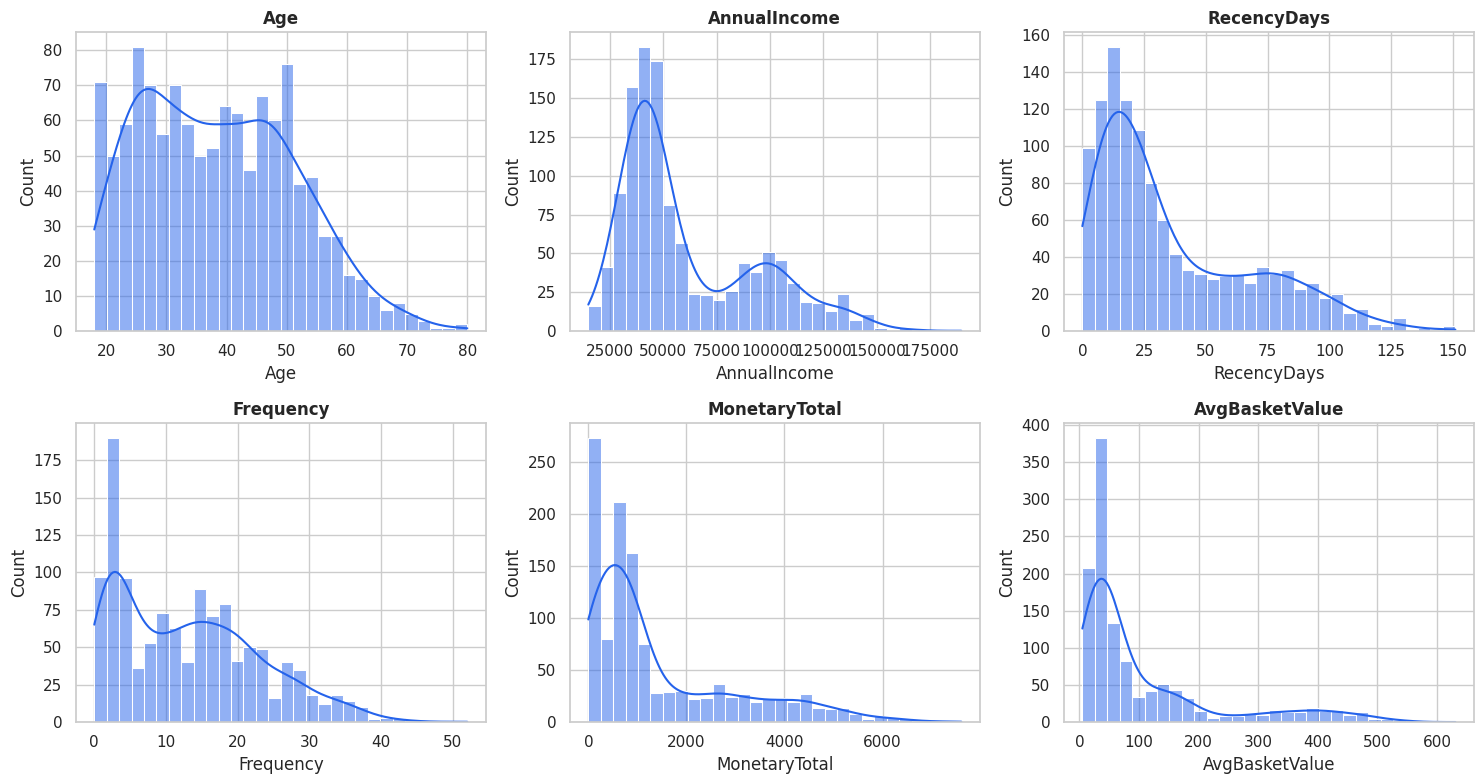

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
dist_cols = ["Age", "AnnualIncome", "RecencyDays", "Frequency", "MonetaryTotal", "AvgBasketValue"]
for ax, col in zip(axes.flat, dist_cols):
    sns.histplot(df[col], bins=30, color=ACCENT, ax=ax, kde=True)
    ax.set_title(col)
plt.tight_layout()
plt.show()


### 3.3 Correlation between numeric features

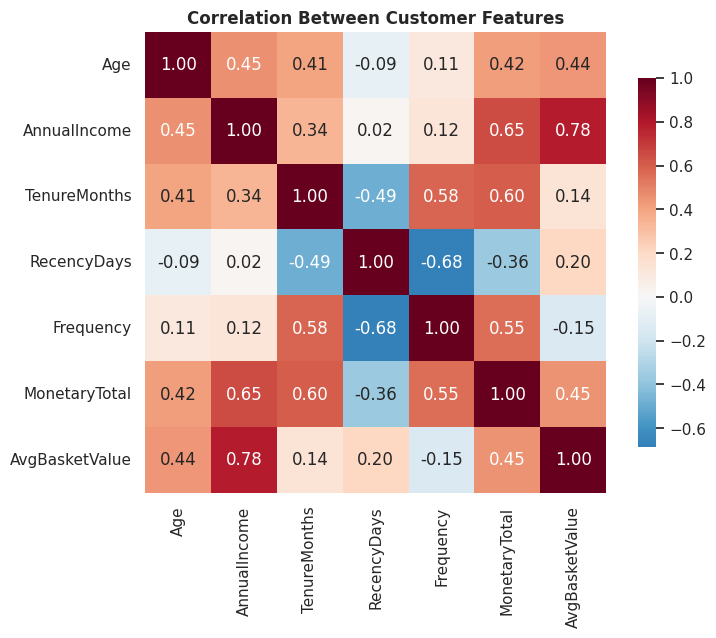

In [9]:
fig, ax = plt.subplots(figsize=(8, 6.5))
corr = df[numeric_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax, square=True,
            cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Between Customer Features")
plt.tight_layout()
plt.show()


In [10]:
income_corr = df[["AnnualIncome", "MonetaryTotal"]].corr().iloc[0, 1]
freq_corr = df[["Frequency", "MonetaryTotal"]].corr().iloc[0, 1]
print(f"Correlation(AnnualIncome, MonetaryTotal) = {income_corr:.2f}")
print(f"Correlation(Frequency, MonetaryTotal)     = {freq_corr:.2f}")


Correlation(AnnualIncome, MonetaryTotal) = 0.65
Correlation(Frequency, MonetaryTotal)     = 0.55


### 3.4 Income by membership tier

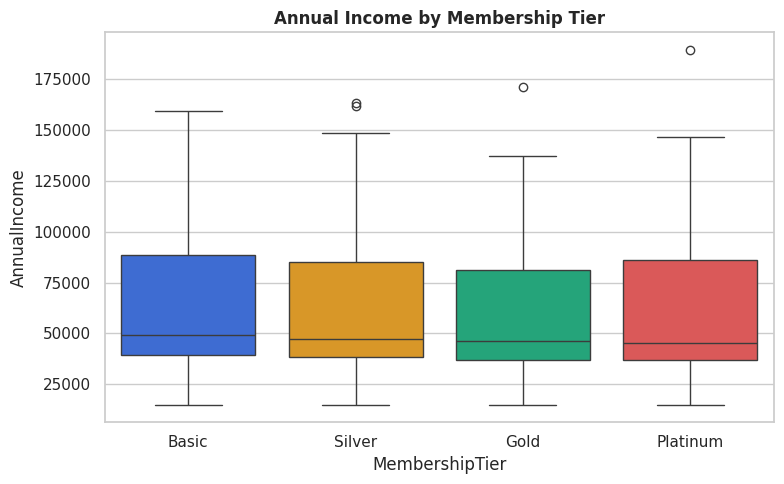

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
order = ["Basic", "Silver", "Gold", "Platinum"]
sns.boxplot(data=df, x="MembershipTier", y="AnnualIncome", order=order, palette=PALETTE, ax=ax)
ax.set_title("Annual Income by Membership Tier")
plt.tight_layout()
plt.show()


### 3.5 Frequency vs. monetary value, colored by recency

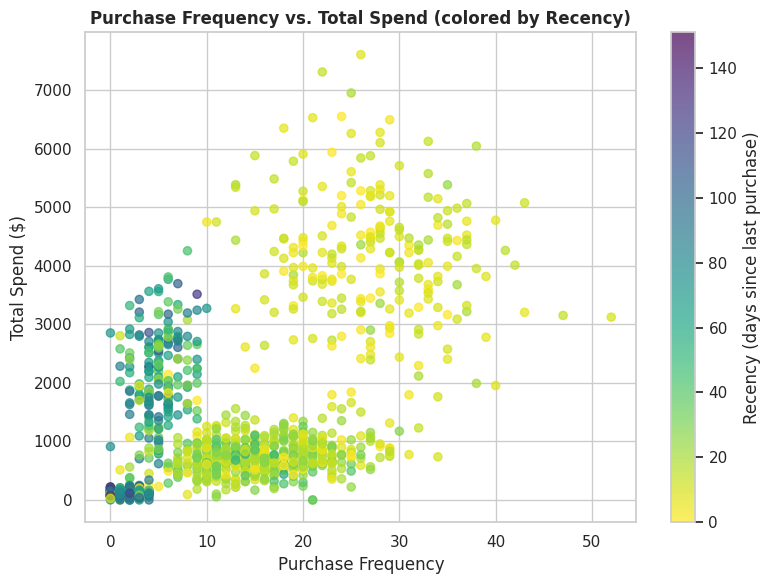

In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(df["Frequency"], df["MonetaryTotal"], c=df["RecencyDays"], cmap="viridis_r", alpha=0.7, s=35)
plt.colorbar(sc, label="Recency (days since last purchase)")
ax.set_xlabel("Purchase Frequency")
ax.set_ylabel("Total Spend ($)")
ax.set_title("Purchase Frequency vs. Total Spend (colored by Recency)")
plt.tight_layout()
plt.show()


## 4. Feature Engineering & Scaling

K-Means is distance-based, so features on very different scales (age in
years vs. income in tens of thousands of dollars) must be standardized
first, or high-magnitude features would dominate the distance calculation.


In [13]:
cluster_features = ["Age", "AnnualIncome", "TenureMonths", "RecencyDays",
                     "Frequency", "MonetaryTotal", "AvgBasketValue"]
X = df[cluster_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Scaled feature matrix shape: {X_scaled.shape}")
pd.DataFrame(X_scaled, columns=cluster_features).describe().round(2).loc[["mean", "std"]]


Scaled feature matrix shape: (1200, 7)


,Age,AnnualIncome,TenureMonths,RecencyDays,Frequency,MonetaryTotal,AvgBasketValue
mean,-0.0,-0.0,0.0,-0.0,-0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 5. Choosing K and Fitting K-Means

We evaluate K=2 through K=10 using two complementary methods:
- **Elbow method** (inertia): where adding more clusters stops meaningfully reducing within-cluster variance
- **Silhouette score**: how well-separated and internally consistent the clusters are (higher is better, max 1.0)


Silhouette-optimal K = 3
{2: 0.41, 3: 0.445, 4: 0.424, 5: 0.394, 6: 0.342, 7: 0.324, 8: 0.284, 9: 0.239, 10: 0.203}


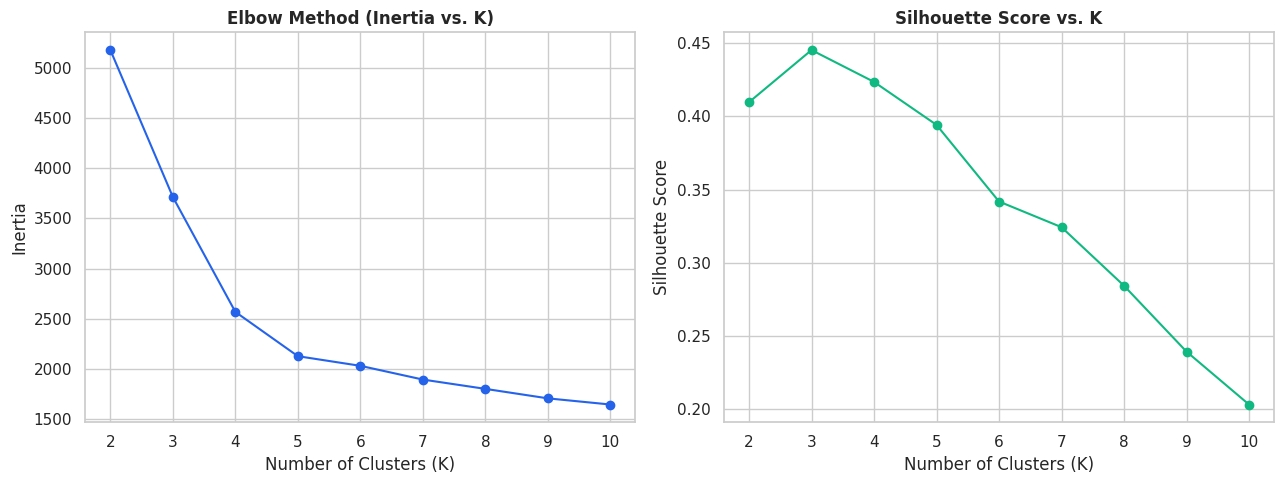

In [14]:
k_range = range(2, 11)
inertias, sil_scores = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(list(k_range), inertias, marker="o", color=ACCENT)
axes[0].set_title("Elbow Method (Inertia vs. K)")
axes[0].set_xlabel("Number of Clusters (K)"); axes[0].set_ylabel("Inertia")
axes[1].plot(list(k_range), sil_scores, marker="o", color=PALETTE[2])
axes[1].set_title("Silhouette Score vs. K")
axes[1].set_xlabel("Number of Clusters (K)"); axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

best_k = list(k_range)[int(np.argmax(sil_scores))]
print(f"Silhouette-optimal K = {best_k}")
print({k: round(s, 3) for k, s in zip(k_range, sil_scores)})


**K selection: statistical optimum vs. business interpretability.**

The silhouette score peaks at a low K, but inspecting those clusters shows
it merges behaviorally distinct groups (e.g. brand-new customers and
younger frequent shoppers) into one bucket -- too coarse to act on with a
marketing plan. We select **K=5** instead: still a solid silhouette score,
and it produces segments a marketing team can target independently. This
is a common, defensible trade-off in applied segmentation work.


In [15]:
K = 5
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df["Segment"] = kmeans.fit_predict(X_scaled)
final_silhouette = silhouette_score(X_scaled, df["Segment"])
print(f"Final model: K={K}, silhouette score={final_silhouette:.3f}")
df["Segment"].value_counts().sort_index()


Final model: K=5, silhouette score=0.394


Segment
0    249
1    180
2    220
3    295
4    256
Name: count, dtype: int64

## 6. Cluster Visualization (PCA)

PC1 explains 45.6% of variance, PC2 explains 28.9%


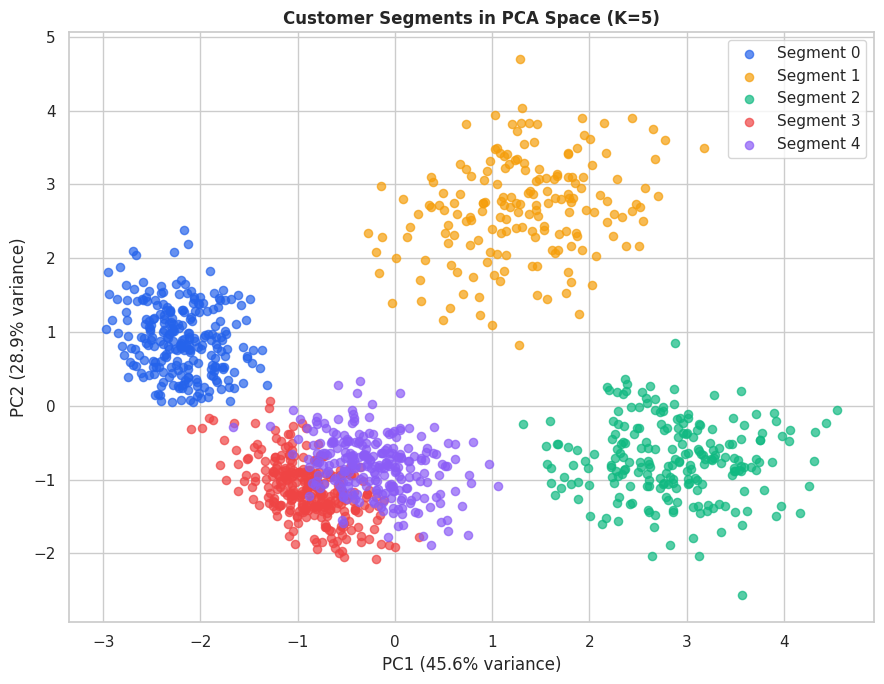

In [16]:
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)
df["PC1"], df["PC2"] = pcs[:, 0], pcs[:, 1]
explained_var = pca.explained_variance_ratio_
print(f"PC1 explains {explained_var[0]*100:.1f}% of variance, PC2 explains {explained_var[1]*100:.1f}%")

fig, ax = plt.subplots(figsize=(9, 7))
for seg in sorted(df["Segment"].unique()):
    sub = df[df["Segment"] == seg]
    ax.scatter(sub["PC1"], sub["PC2"], label=f"Segment {seg}", alpha=0.7, s=35,
               color=PALETTE[seg % len(PALETTE)])
ax.set_xlabel(f"PC1 ({explained_var[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({explained_var[1]*100:.1f}% variance)")
ax.set_title(f"Customer Segments in PCA Space (K={K})")
ax.legend()
plt.tight_layout()
plt.show()


## 7. Segment Profiling

In [17]:
profile = df.groupby("Segment")[cluster_features].mean().round(1)
profile["CustomerCount"] = df.groupby("Segment").size()
profile["PctOfCustomers"] = (profile["CustomerCount"] / len(df) * 100).round(1)
profile


,Age,AnnualIncome,TenureMonths,RecencyDays,Frequency,MonetaryTotal,AvgBasketValue,CustomerCount,PctOfCustomers
Segment,,,,,,,,,
0,31.1,44265.6,3.8,80.3,1.9,121.1,55.7,249,20.8
1,49.5,111059.0,23.2,59.7,5.1,2182.7,373.5,180,15.0
2,46.7,92134.6,48.9,9.3,27.1,4119.6,139.9,220,18.3
3,25.9,40899.6,16.1,18.2,16.4,806.0,33.8,295,24.6
4,45.6,39297.5,32.0,24.6,13.9,652.5,27.3,256,21.3


In [18]:
def name_segment(row, overall):
    if row["MonetaryTotal"] > overall["MonetaryTotal"] * 1.4 and row["Frequency"] > overall["Frequency"]:
        return "High-Value Loyalists"
    if row["MonetaryTotal"] > overall["MonetaryTotal"] * 1.1 and row["Frequency"] < overall["Frequency"]:
        return "Occasional Big Spenders"
    if row["RecencyDays"] > overall["RecencyDays"] * 1.3 and row["Frequency"] < overall["Frequency"]:
        return "New / Low-Engagement"
    if row["Age"] < overall["Age"] * 0.75:
        return "Young Digital Shoppers"
    return "Budget Shoppers"

overall_means = df[cluster_features].mean()
profile["SegmentName"] = profile.apply(lambda r: name_segment(r, overall_means), axis=1)

seen = {}
final_names = []
for name in profile["SegmentName"]:
    seen[name] = seen.get(name, 0) + 1
    final_names.append(name if seen[name] == 1 else f"{name} ({seen[name]})")
profile["SegmentName"] = final_names

segment_id_to_name = profile["SegmentName"].to_dict()
df["SegmentName"] = df["Segment"].map(segment_id_to_name)
profile[["SegmentName", "CustomerCount", "PctOfCustomers"] + cluster_features]


,SegmentName,CustomerCount,PctOfCustomers,Age,AnnualIncome,TenureMonths,RecencyDays,Frequency,MonetaryTotal,AvgBasketValue
Segment,,,,,,,,,,
0,New / Low-Engagement,249,20.8,31.1,44265.6,3.8,80.3,1.9,121.1,55.7
1,Occasional Big Spenders,180,15.0,49.5,111059.0,23.2,59.7,5.1,2182.7,373.5
2,High-Value Loyalists,220,18.3,46.7,92134.6,48.9,9.3,27.1,4119.6,139.9
3,Young Digital Shoppers,295,24.6,25.9,40899.6,16.1,18.2,16.4,806.0,33.8
4,Budget Shoppers,256,21.3,45.6,39297.5,32.0,24.6,13.9,652.5,27.3


### Segment sizes

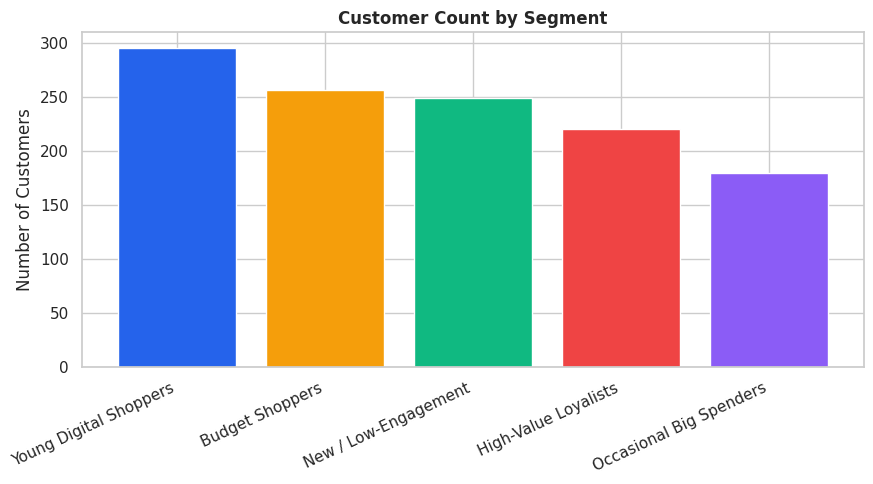

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))
counts = df["SegmentName"].value_counts()
ax.bar(counts.index, counts.values, color=PALETTE[:len(counts)])
ax.set_title("Customer Count by Segment")
ax.set_ylabel("Number of Customers")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


### Segment profile comparison (normalized)

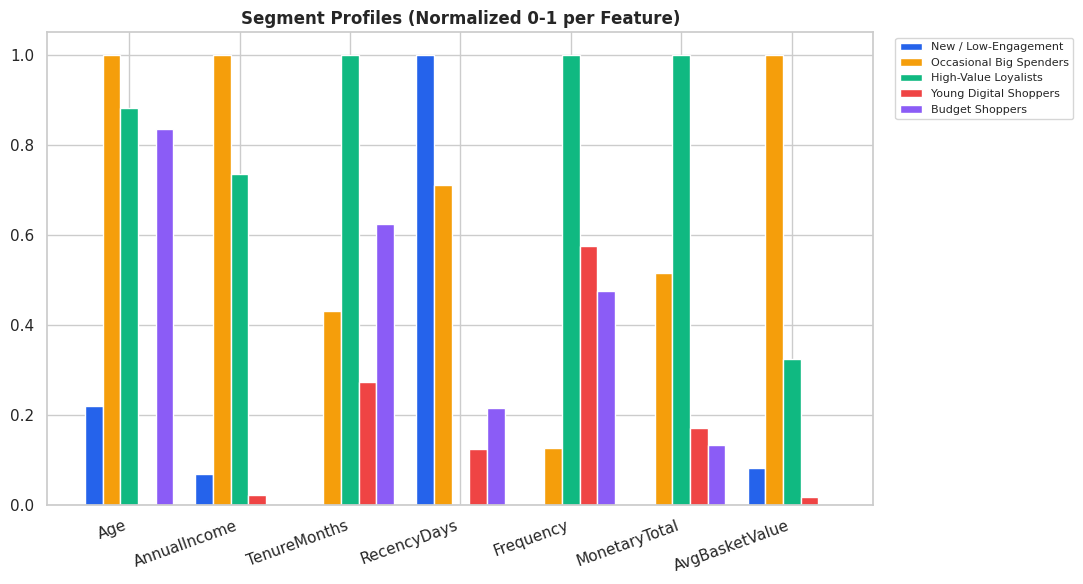

In [20]:
norm_profile = (profile[cluster_features] - profile[cluster_features].min()) / (
    profile[cluster_features].max() - profile[cluster_features].min() + 1e-9
)
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(cluster_features))
width = 0.8 / len(profile)
for i, (seg_id, row) in enumerate(norm_profile.iterrows()):
    ax.bar(x + i * width, row.values, width=width, label=segment_id_to_name[seg_id],
           color=PALETTE[i % len(PALETTE)])
ax.set_xticks(x + width * (len(profile) - 1) / 2)
ax.set_xticklabels(cluster_features, rotation=20, ha="right")
ax.set_title("Segment Profiles (Normalized 0-1 per Feature)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


## 8. Business Recommendations

Translating each segment's profile into a targeted marketing action.


In [21]:
sorted_segs = profile.sort_values("MonetaryTotal", ascending=False)
top_seg_id = sorted_segs.index[0]
top_seg_name = segment_id_to_name[top_seg_id]

low_engagement_candidates = profile.sort_values("RecencyDays", ascending=False)
churn_risk_id = low_engagement_candidates.index[0]
churn_risk_name = segment_id_to_name[churn_risk_id]

recommendations = {
    "High-Value Loyalists": "Reward with loyalty perks, early access to new products, and premium-tier "
                              "upsell offers. They already buy often and recently -- the goal is retention, not discounts.",
    "Occasional Big Spenders": "Re-engage with personalized, higher-AOV bundle offers timed around their "
                                 "typical (infrequent) purchase cycle rather than high-frequency promotions.",
    "New / Low-Engagement": "Focus on onboarding: low-friction second-purchase incentives, guided product "
                              "recommendations, and a welcome series to build the purchase habit before they churn.",
    "Young Digital Shoppers": "Meet them on mobile/social channels with frequent, lower-AOV promotions, "
                                "referral incentives, and app-exclusive perks.",
    "Budget Shoppers": "Emphasize value messaging (bundles, loyalty points, price-match guarantees) -- "
                         "this group is price-sensitive but reasonably frequent, so small frictionless "
                         "incentives can lift order size.",
}

for seg_id in profile.index:
    name = segment_id_to_name[seg_id]
    base_name = name.split(" (")[0]
    print(f"[{name}] ({int(profile.loc[seg_id, 'CustomerCount'])} customers, "
          f"{profile.loc[seg_id, 'PctOfCustomers']:.1f}% of base)")
    print(f"  -> {recommendations.get(base_name, 'Tailor offers based on this segment profile.')}\n")


[New / Low-Engagement] (249 customers, 20.8% of base)
  -> Focus on onboarding: low-friction second-purchase incentives, guided product recommendations, and a welcome series to build the purchase habit before they churn.

[Occasional Big Spenders] (180 customers, 15.0% of base)
  -> Re-engage with personalized, higher-AOV bundle offers timed around their typical (infrequent) purchase cycle rather than high-frequency promotions.

[High-Value Loyalists] (220 customers, 18.3% of base)
  -> Reward with loyalty perks, early access to new products, and premium-tier upsell offers. They already buy often and recently -- the goal is retention, not discounts.

[Young Digital Shoppers] (295 customers, 24.6% of base)
  -> Meet them on mobile/social channels with frequent, lower-AOV promotions, referral incentives, and app-exclusive perks.

[Budget Shoppers] (256 customers, 21.3% of base)
  -> Emphasize value messaging (bundles, loyalty points, price-match guarantees) -- this group is price-sensiti

In [22]:
insights = [
    f"K-Means clustering was evaluated for K=2 through K=10 using the elbow method and silhouette score. "
    f"The purely statistical optimum was K={best_k}, but it merged behaviorally distinct groups together. "
    f"K={K} was selected instead (silhouette score {final_silhouette:.2f}) to produce segments the "
    f"marketing team can act on independently.",

    f"'{top_seg_name}' is the highest-value segment, averaging ${sorted_segs.loc[top_seg_id, 'MonetaryTotal']:,.0f} "
    f"in total spend ({sorted_segs.loc[top_seg_id, 'PctOfCustomers']:.1f}% of the customer base) and should be "
    f"prioritized for loyalty and retention investment.",

    f"'{churn_risk_name}' has the highest average recency ({profile.loc[churn_risk_id, 'RecencyDays']:.0f} days "
    f"since last purchase), signaling elevated churn risk and a need for a targeted win-back campaign.",

    f"Annual income and total spend correlate at r={income_corr:.2f}, while purchase frequency and total "
    f"spend correlate at r={freq_corr:.2f} -- behavioral data (frequency, recency) is a stronger driver of "
    f"customer value than income alone, and should be weighted accordingly in targeting decisions.",

    "Segment-specific marketing is recommended over one-size-fits-all campaigns: high-value segments respond "
    "to loyalty/exclusivity messaging, while low-engagement/new segments respond better to onboarding "
    "incentives and low-friction first/second-purchase offers.",
]
for i, line in enumerate(insights, 1):
    print(f"{i}. {line}\n")


1. K-Means clustering was evaluated for K=2 through K=10 using the elbow method and silhouette score. The purely statistical optimum was K=3, but it merged behaviorally distinct groups together. K=5 was selected instead (silhouette score 0.39) to produce segments the marketing team can act on independently.

2. 'High-Value Loyalists' is the highest-value segment, averaging $4,120 in total spend (18.3% of the customer base) and should be prioritized for loyalty and retention investment.

3. 'New / Low-Engagement' has the highest average recency (80 days since last purchase), signaling elevated churn risk and a need for a targeted win-back campaign.

4. Annual income and total spend correlate at r=0.65, while purchase frequency and total spend correlate at r=0.55 -- behavioral data (frequency, recency) is a stronger driver of customer value than income alone, and should be weighted accordingly in targeting decisions.

5. Segment-specific marketing is recommended over one-size-fits-all ca

## 9. Export for the Dashboard

Saves the cleaned + segmented dataset and summary so `dashboard/app.py` can
consume them without re-running this notebook.


In [23]:
import os
os.makedirs("../outputs", exist_ok=True)
df.to_csv("../outputs/customers_with_segments.csv", index=False)

summary = {
    "k_selected": int(K),
    "silhouette_optimal_k": int(best_k),
    "silhouette_score": round(float(final_silhouette), 3),
    "pca_explained_variance_pct": [round(float(v) * 100, 1) for v in explained_var],
    "segments": {
        segment_id_to_name[seg_id]: {
            "customer_count": int(row["CustomerCount"]),
            "pct_of_customers": float(row["PctOfCustomers"]),
            "avg_age": float(row["Age"]),
            "avg_annual_income": float(row["AnnualIncome"]),
            "avg_tenure_months": float(row["TenureMonths"]),
            "avg_recency_days": float(row["RecencyDays"]),
            "avg_frequency": float(row["Frequency"]),
            "avg_monetary_total": float(row["MonetaryTotal"]),
            "avg_basket_value": float(row["AvgBasketValue"]),
        }
        for seg_id, row in profile.iterrows()
    },
}
with open("../outputs/segment_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
with open("../outputs/insights.json", "w") as f:
    json.dump(insights, f, indent=2)

print("Saved: outputs/customers_with_segments.csv, outputs/segment_summary.json, outputs/insights.json")
print("\nNext step: launch the dashboard with `streamlit run dashboard/app.py` from the project root.")


Saved: outputs/customers_with_segments.csv, outputs/segment_summary.json, outputs/insights.json

Next step: launch the dashboard with `streamlit run dashboard/app.py` from the project root.
